In [4]:
pwd

'c:\\Users\\91918\\rna seq'

In [5]:
import os
os.chdir("C://Users//91918")

In [6]:
pwd

'C:\\Users\\91918'

In [1]:
pip install pandas matplotlib seaborn scipy openpyxl


  Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl (11.5 MB)
Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl (40.9 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.6 MB 5.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Load transcriptome and proteome data
transcriptome = pd.read_excel("overlaps_deg's_O_AL vs DR.xlsx")
proteome = pd.read_excel("overlaps_dep's_O_AL vs DR.xlsx")


In [8]:
# Merge them based on common gene name
# (Assuming common column is 'Gene' — change if needed)
merged = pd.merge(transcriptome, proteome, on='gene', how='inner')

In [10]:
# Extract values for x and y
x = merged['log2FoldChange']        # from transcriptome
y = merged['AVG Log2 Ratio']         # from proteome

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

This line performs linear regression using linregress(). It calculates:

1️. slope → The rate of change in y for every unit increase in x.

Example: If slope = 0.33, it means for every 1 unit increase in mRNA expression, protein expression increases by 0.33 units.

2️.intercept → The value of y when x = 0 (where the regression line crosses the Y-axis).

Example: If intercept = -0.0089, it means when transcriptome log2FC is 0, proteome log2 ratio is -0.0089.

3️. r_value → Correlation coefficient (how strongly x and y are related).

It ranges from -1 to 1:

+1 = Perfect positive correlation

0 = No correlation

-1 = Perfect negative correlation

4️. p_value → The probability that this correlation happened by chance.

A small p-value (p < 0.05) means the correlation is statistically significant.

5️. std_err → Standard error of the slope (how much the slope varies in repeated experiments).



In [11]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

In [12]:
# Create regression line
# np.linspace(min(x), max(x), 100)

# Purpose: This generates 100 evenly spaced values between the minimum (min(x)) and maximum (max(x)) values of x.

# Why? → We need smooth x values to draw the regression line properly, instead of just connecting scattered points.

# y_vals = slope * x_vals + intercept

# This calculates y values using the linear regression equation:

                     # y = ( slope × x ) + intercept

#Now, we have a smooth set of (x, y) values to plot the regression line.

# Why use NumPy?
 
# np.linspace() makes it easier to generate evenly spaced values. like np.linspace(-2, 2, 5) output is [-2, -1, 0, 1, 2] like these are five values from -2 to 2

# Without it, you'd have to manually generate values, which is inefficient.

# Prepare regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

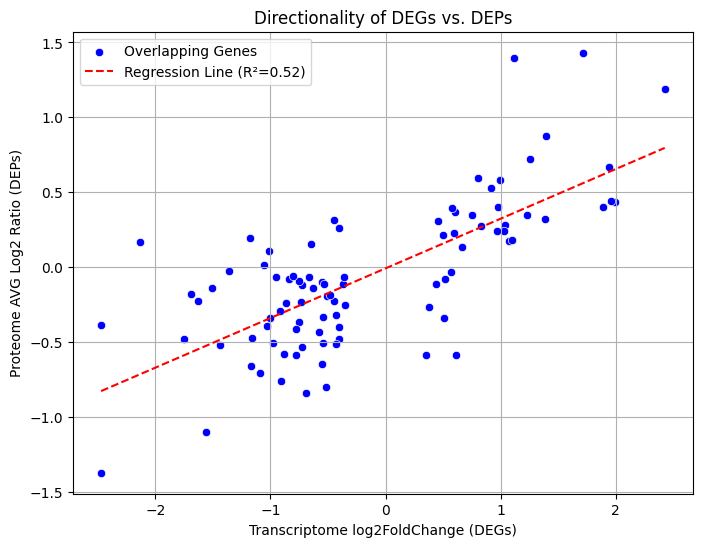

In [13]:
# Plot

# This plots the regression line (red dashed line) using the x_vals and y_vals calculated earlier.
# The R² value (coefficient of determination) is added to the label:
# R² = 0.52 means 52% of the variation in protein expression can be explained by transcriptome changes.



# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='blue', label="Overlapping Genes")
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f"Regression Line (R²={r_value**2:.2f})")

plt.xlabel("Transcriptome log2FoldChange (DEGs)")
plt.ylabel("Proteome AVG Log2 Ratio (DEPs)")
plt.title("Directionality of DEGs vs. DEPs")
plt.legend()                                              # displays the legend box (for the blue dots and red line).
plt.grid(True)                                            #  Adds a grid to improve readability.
#plt.show()


In [14]:
# Save plot
#plt.savefig("C:/Users/91918/Dep_deg_O_AL vs DR Plot.png", dpi=300)

In [15]:
# Print regression stats

# What is r_value?

# r_value is the Pearson correlation coefficient (r) from the linregress(x, y) function.
# It measures the strength and direction of a linear relationship between x and y.

#️ Why r_value**2?

# R² (coefficient of determination) is calculated as r².
# It shows how much of the variation in y is explained by x.

# .4f?

# To avoid too many decimal places (e.g., 0.33162345 → 0.3316).
#Keeps results clean and professional.

# Print equation
print(f"Linear Regression Equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")


Linear Regression Equation: y = 0.3316x + -0.0089
R-squared: 0.5217
P-value: 6.4752e-16


Linear Regression Equation: y = 0.3795x + -0.0166
R-squared: 0.5939
P-value: 1.4190e-29


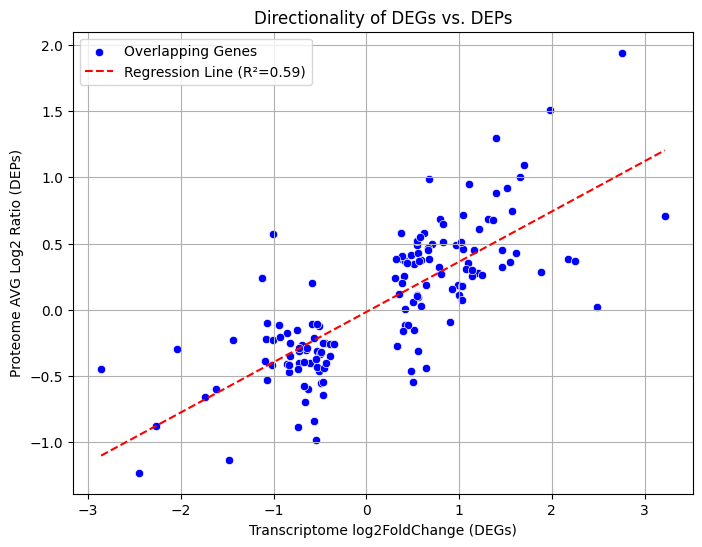

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Load transcriptome and proteome data
transcriptome1 = pd.read_excel("overlaps_deg's_O_AL vs NRDR.xlsx")
proteome1 = pd.read_excel("overlaps_dep's_O_AL vs NRDR.xlsx")

# Merge them based on common gene name
# (Assuming common column is 'Gene' — change if needed)
merged = pd.merge(transcriptome1, proteome1, on='gene', how='inner')

# Extract values for x and y
x = merged['log2FoldChange']        # from transcriptome
y = merged['AVG Log2 Ratio']         # from proteome

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Prepare regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='blue', label="Overlapping Genes")
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f"Regression Line (R²={r_value**2:.2f})")

plt.xlabel("Transcriptome log2FoldChange (DEGs)")
plt.ylabel("Proteome AVG Log2 Ratio (DEPs)")
plt.title("Directionality of DEGs vs. DEPs")
plt.legend()
plt.grid(True)
#plt.show()

# Save plot
plt.savefig("C:/Users/91918/Dep_deg_O_AL vs NRDR Plot.png", dpi=300)


# Print equation
print(f"Linear Regression Equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")


Linear Regression Equation: y = 0.2398x + -0.0800
R-squared: 0.2959
P-value: 1.0004e-18


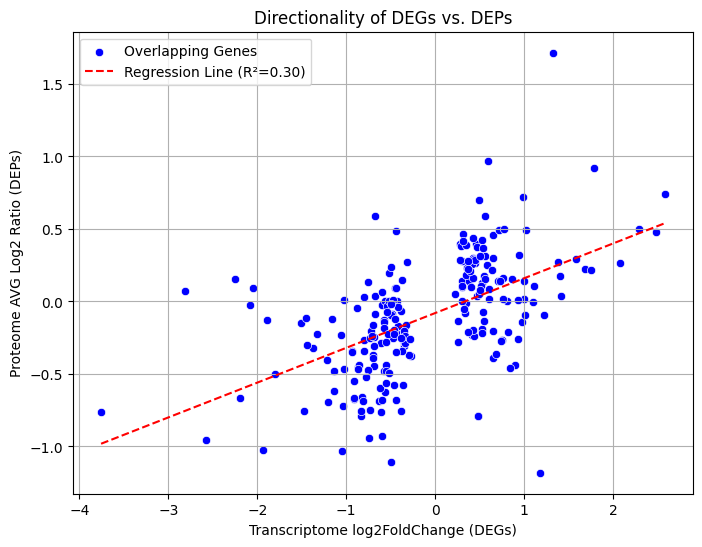

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Load transcriptome and proteome data
transcriptome2 = pd.read_excel("overlaps_deg's_Y_AL vs DR.xlsx")
proteome2 = pd.read_excel("overlaps_dep's_Y_AL vs DR.xlsx")

# Merge them based on common gene name
# (Assuming common column is 'Gene' — change if needed)
merged = pd.merge(transcriptome2, proteome2, on='gene', how='inner')

# Extract values for x and y
x = merged['log2FoldChange']        # from transcriptome
y = merged['AVG Log2 Ratio']         # from proteome

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Prepare regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='blue', label="Overlapping Genes")
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f"Regression Line (R²={r_value**2:.2f})")

plt.xlabel("Transcriptome log2FoldChange (DEGs)")
plt.ylabel("Proteome AVG Log2 Ratio (DEPs)")
plt.title("Directionality of DEGs vs. DEPs")
plt.legend()
plt.grid(True)
#plt.show()

# Save plot
plt.savefig("C:/Users/91918/Dep_deg_Y_AL vs DR Plot.png", dpi=300)


# Print equation
print(f"Linear Regression Equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")


Linear Regression Equation: y = 0.4077x + -0.0467
R-squared: 0.4785
P-value: 8.9637e-39


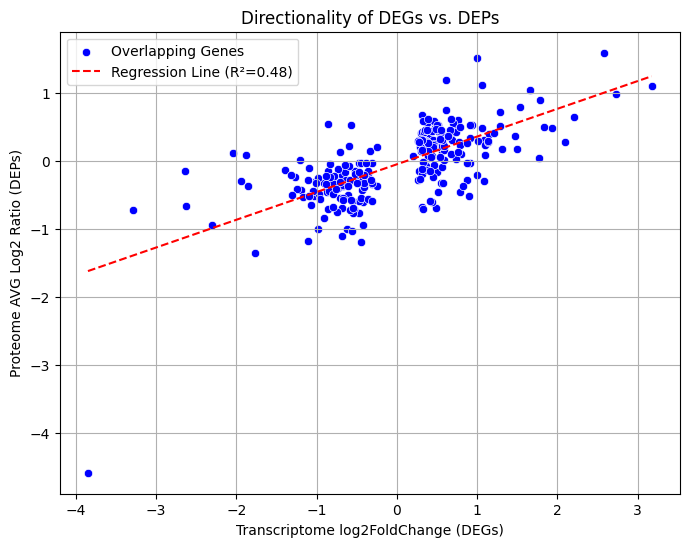

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Load transcriptome and proteome data
transcriptome3 = pd.read_excel("overlaps_deg's_Y_AL vs NRDR.xlsx")
proteome3 = pd.read_excel("overlaps_dep's_Y_AL vs NRDR.xlsx")

# Merge them based on common gene name
# (Assuming common column is 'Gene' — change if needed)
merged = pd.merge(transcriptome3, proteome3, on='gene', how='inner')

# Extract values for x and y
x = merged['log2FoldChange']        # from transcriptome
y = merged['AVG Log2 Ratio']         # from proteome

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Prepare regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='blue', label="Overlapping Genes")
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f"Regression Line (R²={r_value**2:.2f})")

plt.xlabel("Transcriptome log2FoldChange (DEGs)")
plt.ylabel("Proteome AVG Log2 Ratio (DEPs)")
plt.title("Directionality of DEGs vs. DEPs")
plt.legend()
plt.grid(True)
#plt.show()

# Save plot
plt.savefig("C:/Users/91918/Dep_deg_Y_AL vs NRDR Plot.png", dpi=300)

# Print equation
print(f"Linear Regression Equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
